In [1]:
import os

import yaml
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
from torchvision import transforms
from ultralytics import YOLO
from sklearn.model_selection import train_test_split

from bccd.models.models import ResNetCount

In [2]:
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
print(f"Сейчас мы тут: {os.getcwd()}")

Сейчас мы тут: /Users/veronika_steklo/PycharmProjects/ML_NN_SSU/bccd


In [3]:
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 9
sns.set_style('whitegrid')

In [4]:
cfg = yaml.safe_load(open('configs/default.yaml'))
CLASSES = cfg['CLASSES']
CLASS_COLORS = {'WBC': '#e74c3c', 'RBC': '#2ecc71', 'Platelets': '#3498db'}

In [5]:
RESNET_PATH = Path("outputs/models/regression_resnet.pth")
YOLO_PATH = Path("../runs/detect/outputs/detection_yolo/weights/best.pt")

In [6]:
device = "mps" if torch.backends.mps.is_available() else "cpu"

In [7]:
resnet = ResNetCount(num_classes=len(CLASSES)).to(device)
resnet.load_state_dict(torch.load(RESNET_PATH, map_location=device, weights_only=True))
resnet.eval()

ResNetCount(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
     

In [8]:
yolo = YOLO(str(YOLO_PATH))

In [9]:
df = pd.read_csv("dataset/regression_targets.csv")
_, val_df = train_test_split(df, test_size=0.2, random_state=cfg["SEED"])
val_df = val_df.reset_index(drop=True)

In [10]:
eval_transform = transforms.Compose([
    transforms.Resize((cfg["IMG_SIZE"], cfg["IMG_SIZE"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [11]:
def draw_yolo_boxes(img_path, results, classes, colors):
    """Рисует bounding boxes от YOLO на изображении"""
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.truetype("Arial.ttf", 14)
    except:
        font = ImageFont.load_default()

    boxes = results[0].boxes
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        cls_name = classes[cls_id] if cls_id < len(classes) else f"Class_{cls_id}"
        color = colors.get(cls_name, 'yellow')

        draw.rectangle([x1, y1, x2, y2], outline=color, width=2)
        label = f"{cls_name} {conf:.2f}"
        draw.text((x1, y1-20), label, fill=color, font=font)

    return img

In [12]:
def make_prediction_row(img_path, gt_counts, resnet_pred, yolo_results, classes):
    img_gt = Image.open(img_path).convert("RGB")
    draw_gt = ImageDraw.Draw(img_gt)
    try:
        font = ImageFont.truetype("Arial.ttf", 16)
    except:
        font = ImageFont.load_default()

    gt_text = "Ground Truth:\n" + "\n".join([f"{c}: {int(gt_counts[i])}" for i, c in enumerate(classes)])
    draw_gt.text((10, 10), gt_text, fill='white', font=font, stroke_width=1, stroke_fill='black')

    img_resnet = Image.open(img_path).convert("RGB")
    draw_resnet = ImageDraw.Draw(img_resnet)
    resnet_text = "ResNet Regression:\n" + "\n".join([f"{c}: {int(resnet_pred[i])}" for i, c in enumerate(classes)])
    draw_resnet.text((10, 10), resnet_text, fill='white', font=font, stroke_width=1, stroke_fill='black')
    draw_resnet.rectangle([0, 0, img_resnet.width-1, img_resnet.height-1], outline='#2ecc71', width=3)

    img_yolo = draw_yolo_boxes(img_path, yolo_results, classes, CLASS_COLORS)
    draw_yolo = ImageDraw.Draw(img_yolo)
    yolo_counts = {0: 0, 1: 0, 2: 0}
    for box in yolo_results[0].boxes:
        cls_id = int(box.cls[0])
        if cls_id in yolo_counts:
            yolo_counts[cls_id] += 1
    yolo_text = "YOLO Detection:\n" + "\n".join([f"{c}: {yolo_counts[i]}" for i, c in enumerate(classes)])
    draw_yolo.text((10, 10), yolo_text, fill='white', font=font, stroke_width=1, stroke_fill='black')
    draw_yolo.rectangle([0, 0, img_yolo.width-1, img_yolo.height-1], outline='#3498db', width=3)

    return img_gt, img_resnet, img_yolo

In [13]:
import random
random.seed(42)
idx = random.randint(0, len(val_df)-1)

row = val_df.iloc[idx]
img_path = row['image_path']
gt_counts = row[CLASSES].values

In [14]:
img_pil = Image.open(img_path).convert("RGB")
tensor = eval_transform(img_pil).unsqueeze(0).to(device)
with torch.no_grad():
    resnet_pred = torch.round(resnet(tensor)).clamp(min=0).cpu().numpy().squeeze()

In [15]:
yolo_results = yolo.predict(img_path, imgsz=cfg["IMG_SIZE"], conf=0.25, verbose=False)

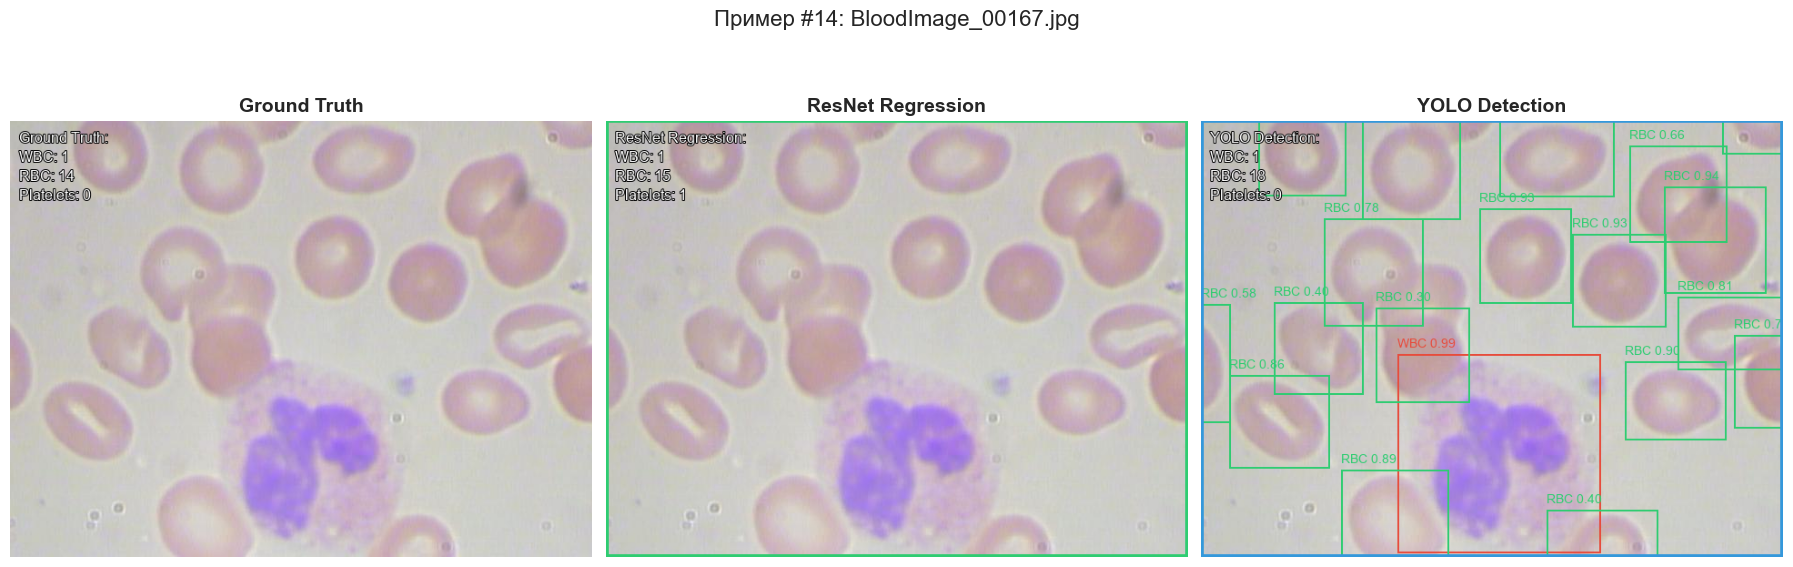

In [16]:
imgs = make_prediction_row(img_path, gt_counts, resnet_pred, yolo_results, CLASSES)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = ['Ground Truth', 'ResNet Regression', 'YOLO Detection']
for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
plt.suptitle(f'Пример #{idx}: {Path(img_path).name}', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
errors = []
for idx, row in val_df.iterrows():
    img_path = row['image_path']
    gt = row[CLASSES].values

    img_pil = Image.open(img_path).convert("RGB")
    tensor = eval_transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = torch.round(resnet(tensor)).clamp(min=0).cpu().numpy().squeeze()

    err = np.sum(np.abs(gt - pred))
    errors.append((idx, err, gt, pred))

In [18]:
errors_sorted = sorted(errors, key=lambda x: x[1])
best_idx = errors_sorted[0][0]
worst_idx = errors_sorted[-1][0]

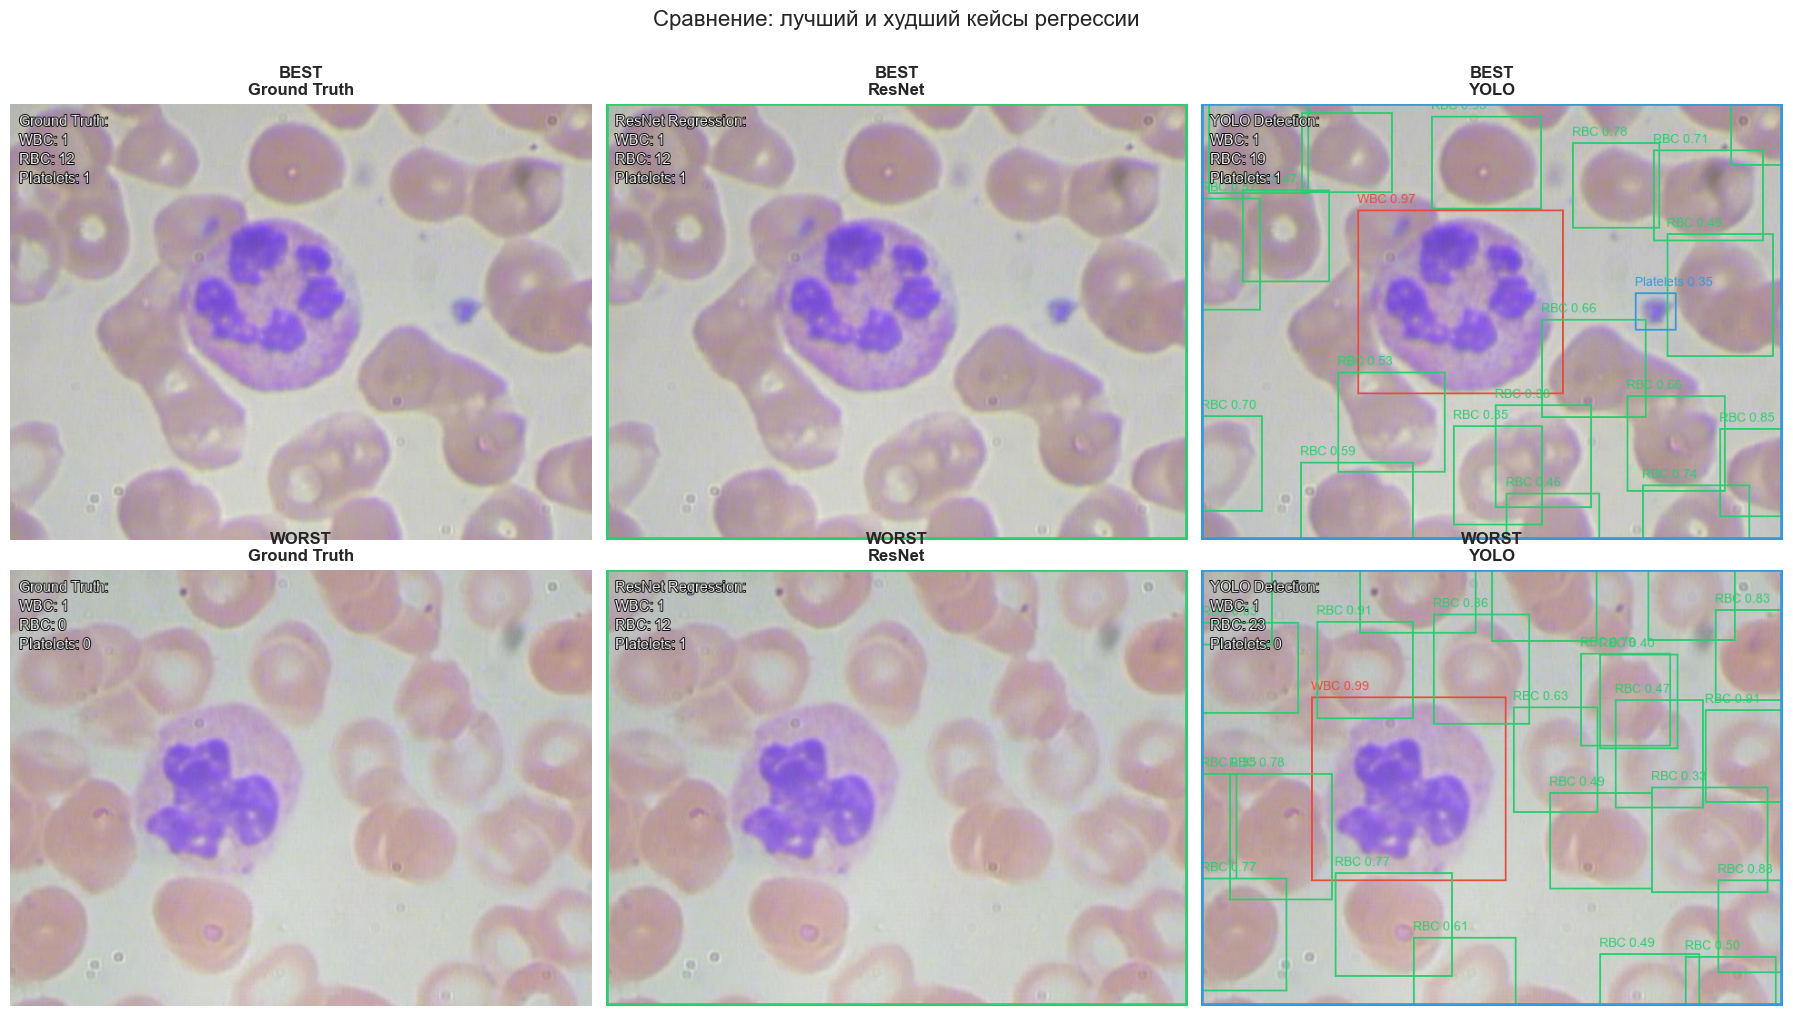

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row_idx, (title_prefix, sample_idx) in enumerate([("BEST", best_idx), ("WORST", worst_idx)]):
    row = val_df.iloc[sample_idx]
    img_path = row['image_path']
    gt_counts = row[CLASSES].values

    img_pil = Image.open(img_path).convert("RGB")
    tensor = eval_transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        resnet_pred = torch.round(resnet(tensor)).clamp(min=0).cpu().numpy().squeeze()
    yolo_results = yolo.predict(img_path, imgsz=cfg["IMG_SIZE"], conf=0.25, verbose=False)

    imgs = make_prediction_row(img_path, gt_counts, resnet_pred, yolo_results, CLASSES)

    for col, (img, base_title) in enumerate(zip(imgs, ['Ground Truth', 'ResNet', 'YOLO'])):
        ax = axes[row_idx, col]
        ax.imshow(img)
        ax.set_title(f"{title_prefix}\n{base_title}", fontsize=12, fontweight='bold')
        ax.axis('off')

plt.suptitle('Сравнение: лучший и худший кейсы регрессии', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [20]:
rbc_errors = []
for idx, row in val_df.iterrows():
    img_path = row['image_path']
    gt = row[CLASSES].values
    img_pil = Image.open(img_path).convert("RGB")
    tensor = eval_transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = torch.round(resnet(tensor)).clamp(min=0).cpu().numpy().squeeze()
    rbc_err = abs(gt[1] - pred[1])
    rbc_errors.append((idx, rbc_err, gt, pred))

rbc_errors_sorted = sorted(rbc_errors, key=lambda x: x[1], reverse=True)
sample_idx = rbc_errors_sorted[0][0]

In [21]:
row = val_df.iloc[sample_idx]
img_path = row['image_path']
gt_counts = row[CLASSES].values

In [22]:
img_pil = Image.open(img_path).convert("RGB")
tensor = eval_transform(img_pil).unsqueeze(0).to(device)
with torch.no_grad():
    resnet_pred = torch.round(resnet(tensor)).clamp(min=0).cpu().numpy().squeeze()
yolo_results = yolo.predict(img_path, imgsz=cfg["IMG_SIZE"], conf=0.25, verbose=False)


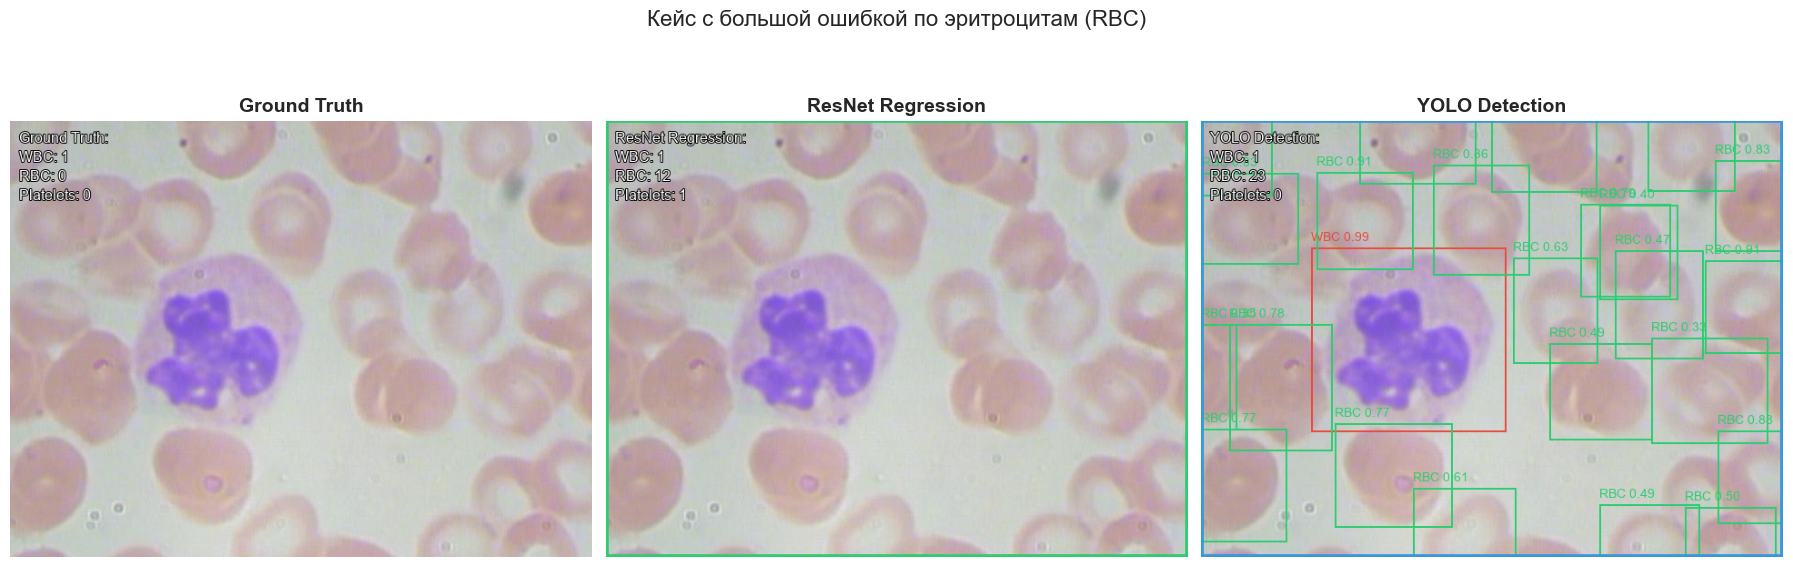

In [23]:
imgs = make_prediction_row(img_path, gt_counts, resnet_pred, yolo_results, CLASSES)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, img, title in zip(axes, imgs, ['Ground Truth', 'ResNet Regression', 'YOLO Detection']):
    ax.imshow(img)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
plt.suptitle(f'Кейс с большой ошибкой по эритроцитам (RBC)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
all_preds_resnet = []
all_preds_yolo = []
all_gts = []

for idx, row in val_df.iterrows():
    img_path = row['image_path']
    gt = row[CLASSES].values

    img_pil = Image.open(img_path).convert("RGB")
    tensor = eval_transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        pred_r = torch.round(resnet(tensor)).clamp(min=0).cpu().numpy().squeeze()

    yolo_results = yolo.predict(img_path, imgsz=cfg["IMG_SIZE"], conf=0.25, verbose=False)
    counts = [0, 0, 0]
    for box in yolo_results[0].boxes:
        cls_id = int(box.cls[0])
        if cls_id < 3:
            counts[cls_id] += 1
    pred_y = np.array(counts)

    all_gts.append(gt)
    all_preds_resnet.append(pred_r)
    all_preds_yolo.append(pred_y)

all_gts = np.array(all_gts)
all_preds_resnet = np.array(all_preds_resnet)
all_preds_yolo = np.array(all_preds_yolo)

In [25]:
print(f"{'Class':<12} {'GT mean':>8} {'ResNet MAE':>12} {'YOLO MAE':>12} {'Rel.Err.ResNet':>15} {'Rel.Err.YOLO':>13}")
for i, cls in enumerate(CLASSES):
    gt_mean = all_gts[:, i].mean()
    mae_r = np.mean(np.abs(all_gts[:, i] - all_preds_resnet[:, i]))
    mae_y = np.mean(np.abs(all_gts[:, i] - all_preds_yolo[:, i]))
    rel_r = mae_r / (gt_mean + 1e-6) * 100
    rel_y = mae_y / (gt_mean + 1e-6) * 100
    print(f"{cls:<12} {gt_mean:>8.1f} {mae_r:>12.2f} {mae_y:>12.2f} {rel_r:>14.1f}% {rel_y:>12.1f}%")


Class         GT mean   ResNet MAE     YOLO MAE  Rel.Err.ResNet  Rel.Err.YOLO
WBC               1.0         0.07         0.33            6.6%         31.6%
RBC              11.0         2.92         6.81           26.5%         61.7%
Platelets         1.0         0.97         0.78          100.0%         80.3%
